In [ ]:
!pip install miceforest --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 874.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 148.0 MB/s eta 0:00:00


In [ ]:
import gzip
from shutil import copyfileobj
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
from keras.utils import get_file

url = "https://data.insideairbnb.com/sweden/stockholms-l%C3%A4n/stockholm/2024-03-30/data/listings.csv.gz"

path = get_file("listings.csv.gz", origin=url, cache_dir='.', cache_subdir='')

# Extract the csv file
with gzip.open('listings.csv.gz', 'rb') as f_in:
    with open('listings.csv', 'wb') as f_out:
        copyfileobj(f_in, f_out)

2302810/2302810 [==============================] - 0s 0us/step


In [ ]:
import polars as pl
import ast
import re

# Function to transform english numerotation into french numerotation (1,200.00 => 1200.00)
def floatFormat(text: str) -> str:
    return text.replace(",", "")

# Load the dataframe without the amenities
data = (pl.scan_csv('listings.csv')
        .select(['price', 'latitude', 'longitude', 'bathrooms', 'bedrooms'])
        .with_columns(pl.col('price').map_elements(floatFormat).str.strip_prefix("$").alias("price").cast(pl.Float64))
        .with_columns(pl.col('latitude').fill_null(strategy="zero"))
        .with_columns(pl.col('longitude').fill_null(strategy="zero"))
        .with_columns(pl.col('bathrooms').fill_null(strategy="zero"))
        .with_columns(pl.col('bedrooms').fill_null(strategy="zero"))
        .collect())

# Load the amenities that need to be prepocessed
data_amenities = (pl.scan_csv('listings.csv')
        .select(['amenities'])
        .collect())

# Change to pandas.DataFrame
df = data.to_pandas()
df['rooms'] = df['bathrooms'] + df['bedrooms']
df = df.drop('bathrooms', axis=1)
df = df.drop('bedrooms', axis=1)

df_amenities = data_amenities.to_pandas()

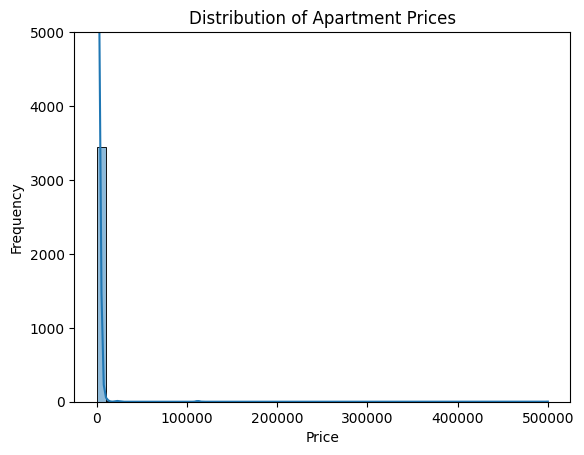

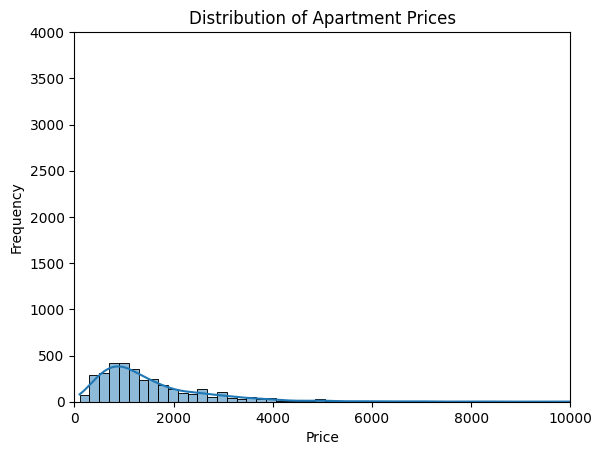

count      3459.000000
mean       1918.882336
std        9582.672956
min         105.000000
25%         786.000000
50%        1200.000000
75%        2000.000000
max      500000.000000
Name: price, dtype: float64


In [ ]:
# Data study
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Apartment Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.ylim([0, 5000])
plt.show()

df_tmp = df.copy()
df_tmp = df_tmp.drop(df_tmp[df_tmp.price > 10000].index)

sns.histplot(df_tmp['price'], bins=50, kde=True)
plt.title('Distribution of Apartment Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.ylim([0, 4000])
plt.xlim([0, 10000])
plt.show()

# Descriptive pricing statistics
price_stats = df['price'].describe()
print(price_stats)

In [ ]:
# Delete the high outliers
Q = df['price'].quantile(0.9)
print(Q)

df = df.drop(df[df.price > Q].index)

df.info()

# Descriptive pricing statistics
price_stats = df['price'].describe()
print(price_stats)

3000.0
<class 'pandas.core.frame.DataFrame'>
Index: 4381 entries, 0 to 4715
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      3124 non-null   float64
 1   latitude   4381 non-null   float64
 2   longitude  4381 non-null   float64
 3   rooms      4381 non-null   float64
dtypes: float64(4)
memory usage: 171.1 KB
count    3124.000000
mean     1263.942382
std       694.584176
min       105.000000
25%       729.000000
50%      1100.000000
75%      1678.500000
max      3000.000000
Name: price, dtype: float64


In [ ]:
# Function to clean the amenities format
def clean_word_list(word_list_str: str) -> str:
    cleaned_str = re.sub(r'\s+', ' ', word_list_str)  # Remove extra spaces
    cleaned_str.replace('\\u', '') # Remove '\u' before numbers
    return cleaned_str

# Apply the clean function
df_amenities['amenities'] = df_amenities['amenities'].apply(clean_word_list)

# Convert strings into word lists
df_amenities['amenities'] = df_amenities['amenities'].apply(lambda x: ast.literal_eval(x))

# Reformat the amenitites so that the MICE algorithm will be able to run
df_amenities['amenities'] = df_amenities['amenities'].apply(lambda x: [re.sub('[^A-Za-z0-9_ÅåÄäÖö ]+', '', y.lower()) for y in x])

# Get all the amenities into a list
list = df_amenities['amenities'].copy()
list = list.apply(lambda x: ','.join(x))
list = list.str.get_dummies(sep=',').columns
list = list.to_list()

for x in list:
  x = ' '.join(x.split())

# Set the list of all smallest amenities, the essential amenities to keep relevant information (example: Yamahaa TV => TV)
list2 = list.copy()
list3 = list.copy()
for l in list:
  for ll in list2:
    if(l!=ll) and (l in ll) and list3.count(ll)>0:
        list3.remove(ll)

# Get the list of the essential amenities include in a string of amenities
def contains_or_delete(word_list_str: str) -> str:
  res = ""
  for word in list3:
    if word in word_list_str:
     res = res + "," + word
  return res

# Filter all the amenities to get all the essential ones
df_amenities['amenities'] = df_amenities['amenities'].apply(lambda x: [contains_or_delete(y) for y in x])

# Convert lists into ','-separated character strings
df_amenities['amenities'] = df_amenities['amenities'].apply(lambda x: ','.join(x))

# Use get_dummies to create binary columns
df_dummies = df_amenities['amenities'].str.get_dummies(sep=',')

# Join the dataframes
df_preprocessed = df.join(df_dummies)

df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4381 entries, 0 to 4715
Columns: 170 entries, price to wine glasses
dtypes: float64(4), int64(166)
memory usage: 5.8 MB


In [ ]:
import miceforest as mf

# Create MICE kernel
kds = mf.ImputationKernel(
  df_preprocessed,
  save_all_iterations=True,
  random_state=100
)

# Apply MICE algorithm to impute missing prices
kds.mice(iterations=50, n_estimators=200)

df_imputed = kds.complete_data()

list_amenities = df_imputed.drop('price',axis=1).drop('latitude',axis=1).drop('longitude',axis=1).drop('rooms',axis=1).copy().columns.to_list()

df_imputed.info()

# Descriptive pricing statistics
price_stats = df_imputed['price'].describe()
print(price_stats)

<class 'pandas.core.frame.DataFrame'>
Index: 4381 entries, 0 to 4715
Columns: 170 entries, price to wine glasses
dtypes: float64(4), int64(166)
memory usage: 5.8 MB
count    4381.000000
mean     1237.566766
std       654.473053
min       105.000000
25%       750.000000
50%      1100.000000
75%      1600.000000
max      3000.000000
Name: price, dtype: float64


In [ ]:
df_imputed.head()

,price,latitude,longitude,rooms,ac split type ductless system,air conditioning,arcade games,baby bath,baby monitor,babysitter recommendations,...,toaster,trash compactor,tv,valley view,washer,waterfront,wifi,window ac unit,window guards,wine glasses
0,1385.0,59.32779,18.04998,2.0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,924.0,59.31389,18.06087,2.0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
2,1142.0,59.31702,18.02946,2.5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,450.0,59.33351,18.03693,2.0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
4,1279.0,59.33872,18.05131,2.0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Divide data into learning and test sets
train_dataset = df_imputed.sample(frac=0.8, random_state=0)
test_dataset = df_imputed.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('price')
test_labels = test_features.pop('price')

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))

In [ ]:
# FIRST MODEL: Regression using a DNN and several inputs

from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping

def build_and_compile_model(norm):
  model = keras.Sequential([
      norm,
      layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(len(train_features.columns),)),
      layers.BatchNormalization(),
      layers.Dropout(0.4),
      layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
      layers.BatchNormalization(),
      layers.Dropout(0.4),
      layers.Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 169)               339       
 on)                                                             
                                                                 
 dense (Dense)               (None, 256)               43520     
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1

Epoch 1/100
44/44 [==============================] - 2s 13ms/step - loss: 1244.9039 - val_loss: 1213.1112 - lr: 0.0010
Epoch 2/100
44/44 [==============================] - 0s 9ms/step - loss: 1242.9688 - val_loss: 1210.8201 - lr: 0.0010
Epoch 3/100
44/44 [==============================] - 0s 7ms/step - loss: 1240.3414 - val_loss: 1207.3419 - lr: 0.0010
Epoch 4/100
44/44 [==============================] - 0s 8ms/step - loss: 1236.0323 - val_loss: 1202.0798 - lr: 0.0010
Epoch 5/100
44/44 [==============================] - 0s 8ms/step - loss: 1229.3993 - val_loss: 1194.0740 - lr: 0.0010
Epoch 6/100
44/44 [==============================] - 0s 7ms/step - loss: 1220.3286 - val_loss: 1183.7084 - lr: 0.0010
Epoch 7/100
44/44 [==============================] - 0s 8ms/step - loss: 1208.0541 - val_loss: 1169.9327 - lr: 0.0010
Epoch 8/100
44/44 [==============================] - 1s 12ms/step - loss: 1193.2505 - val_loss: 1152.7511 - lr: 0.0010
Epoch 9/100
44/44 [==============================] - 1

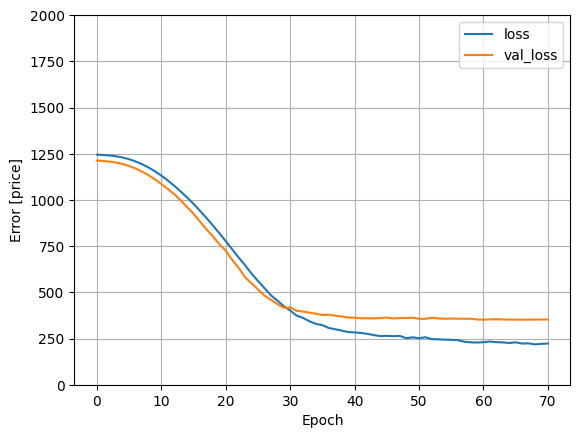

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Training and validation

early_stop = EarlyStopping(monitor='val_loss', patience=10)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6)

history = dnn_model.fit(
                    train_features,
                    train_labels,
                    epochs=100,
                    validation_split=0.2,
                    batch_size=64,
                    callbacks=[early_stop,reduce_lr])

def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 2000])
  plt.xlabel('Epoch')
  plt.ylabel('Error [price]')
  plt.legend()
  plt.grid(True)

plot_loss(history)

28/28 [==============================] - 0s 4ms/step
Mean Absolute Error: 363.7553567755712


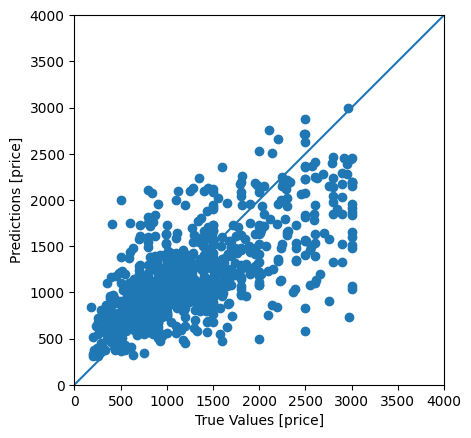

In [ ]:
from sklearn.metrics import mean_absolute_error

test_predictions = dnn_model.predict(test_features)
mae = mean_absolute_error(test_labels, test_predictions)
print("Mean Absolute Error:", mae)

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [price]')
plt.ylabel('Predictions [price]')
lims = [0, 4000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [ ]:
# SECOND MODEL: XGBoost

from numpy import asarray
from numpy import absolute
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

# define model
XGBmodel = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

# define model evaluation method
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# evaluate model
scores = cross_val_score(XGBmodel, train_features, train_labels, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

# force scores to be positive
scores = absolute(scores)
print('MAE (std): %.3f (%.3f)' % (scores.mean(), scores.std()) )

# fit model
XGBmodel.fit(train_features.values, train_labels)

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


MAE (std): 333.278 (11.154)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

Mean Absolute Error: 325.5393576774423


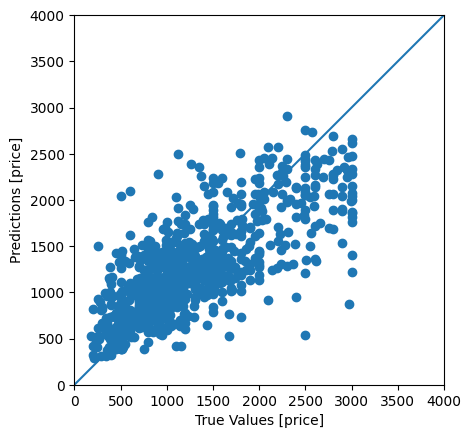

In [ ]:
test_predictions = XGBmodel.predict(test_features)
mae = mean_absolute_error(test_labels, test_predictions)
print("Mean Absolute Error:", mae)

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [price]')
plt.ylabel('Predictions [price]')
lims = [0, 4000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [ ]:
# THIRD MODEL: Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
import numpy as np

# Random Forest model creation
RFmodel = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=4,
    max_depth=100,
    bootstrap=True,
    random_state=42
)

# K-fold cross validation definition
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross validation with Mean Absolute Error (MAE)
mae_scores = -cross_val_score(RFmodel, train_features, train_labels, cv=kf, scoring='neg_mean_absolute_error')

# Calculation of the average and standard deviation of MAE scores
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

# Displaying results
print("Mean MAE for cross validation:", mean_mae)
print("Standard deviation of MAE scores:", std_mae)

# fit model
RFmodel.fit(train_features.values, train_labels)

Mean MAE for cross validation: 329.35417670279037
Standard deviation of MAE scores: 13.524483428423085


RandomForestRegressor(max_depth=100, min_samples_leaf=4, min_samples_split=5,
                      random_state=42)

Mean Absolute Error: 316.2204084791209


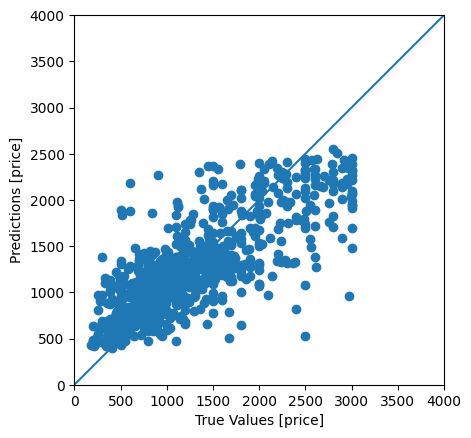

In [ ]:
test_predictions = RFmodel.predict(test_features.values)
mae = mean_absolute_error(test_labels, test_predictions)
print("Mean Absolute Error:", mae)

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [price]')
plt.ylabel('Predictions [price]')
lims = [0, 4000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [ ]:
import pandas as pd

user_data = {'latitude': 59.327790, 'longitude': 18.049980, 'rooms': 2, 'elevator': 1.0, 'essentials': 1.0, 'gym': 1.0, 'heating': 1.0, 'kitchen': 1.0, 'wifi': 1.0}

df_user = pd.DataFrame([user_data])
df_user_amenities = df_user.copy().drop('latitude',axis=1).drop('longitude',axis=1).drop('rooms',axis=1)

for user_amenitie in df_user_amenities.columns.to_list():
  if user_amenitie not in list_amenities:
    print(user_amenitie)
    df_user = df_user.drop(user_amenitie, axis=1)

user_vector = pd.concat([df_imputed, df_user], ignore_index=True).iloc[-1].fillna(0)
user_vector.pop('price')

new_data = asarray([user_vector])

# dnn prediction
dnn_prediction = dnn_model.predict(new_data)
print(dnn_prediction[-1])

# XGBoost prediction
XGB_prediction = XGBmodel.predict(new_data)
print(XGB_prediction)

# rf prediction
RF_prediction = RFmodel.predict(new_data)
print(RF_prediction)

print(f"Expected price should be of {df_imputed.iloc[0]['price']}")

1/1 [==============================] - 1s 532ms/step
[1018.15027]
[1231.5775]
[1039.22400666]
Expected price should be of 1385.0


In [ ]:
import pandas as pd

def suggest_amenities(user_input, amenities, model):
    # Get a vector of the size of the model input
    df_user = pd.DataFrame([user_data])
    df_user_amenities = df_user.copy().drop('latitude',axis=1).drop('longitude',axis=1).drop('rooms',axis=1)

    for user_amenitie in df_user_amenities.columns.to_list():
      if user_amenitie not in list_amenities:
        df_user = df_user.drop(user_amenitie, axis=1)

    user_vector = pd.concat([df_imputed, df_user], ignore_index=True).iloc[-1].fillna(0)
    user_vector.pop('price')

    current_data = asarray([user_vector])
    current_price = model.predict(current_data)
    price_increases = {}

    for amenity in amenities:
        new_input = user_vector.copy()
        new_input[amenity] = 1  # add the amenity
        new_data = asarray([new_input])
        new_price = model.predict(new_data)
        price_increase = new_price[-1] - current_price[-1]
        price_increases[amenity] = price_increase

    # Sort amenities by price increase and return the top few
    suggested_amenities = sorted(price_increases, key=price_increases.get, reverse=True)

    return suggested_amenities[:5]  # return the top 5 amenities


user_data = {'latitude': 59.327790, 'longitude': 18.049980, 'rooms': 2, 'elevator': 1.0, 'essentials': 1.0, 'gym': 1.0, 'heating': 1.0, 'kitchen': 1.0, 'wifi': 1.0}
suggest_amenities(user_data, list_amenities, dnn_model)

NameError: name 'list_amenities' is not defined